<a href="https://colab.research.google.com/github/prof-atritiack/CHECKPOINT_02_1CCPH_SERS/blob/main/AULA_06_SERS_ML_Energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##EXERCÍCIO

Treinar um modelo preditivo de classificação binária. O modelo fará as previsões com base nos dados da coluna 'stabf' mostrando se a rede elétrica está INSTÁVEL ou ESTÁVEL. Utilizar o algoritmo Regressão Logística (Logistic Regression do sklearn) para o treinamento do modelo. Avaliar o modelo com base na acurácia. Apresentar a Matriz de Confusão.


##PREPARAÇÃO DO AMBIENTE

In [1]:
# Manipulação de tabelas e matrizes/vetores
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
# Algoritmo de regressão logística
from sklearn.linear_model import LogisticRegression
# Ferramenta para separação dos dados de treino e teste
# X_train, X_test, y_train, y_test
from sklearn.model_selection import train_test_split
# Avaliação com acurácia e matriz de confusão
from sklearn.metrics import accuracy_score, confusion_matrix

##CARREGAR OS DADOS E CRIAR O DATAFRAME


In [2]:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_1CCPH_SERS/refs/heads/main/Data_for_UCI_named.csv')
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


## REALIZAR A INSPEÇÃO BÁSICA DOS DADOS

In [3]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [7]:
# Número de registros
dados.shape[0]

10000

In [5]:
# Quantas classes existem na coluna 'stabf'?
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [6]:
# Quantos registros existem de cada classe na coluna 'stabf'?
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


In [4]:
# Estatísticas descritivas
# Para atributos categóricos
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [8]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

## SEPARAÇÃO DE DADOS DE ENTRADA (FEATURES) E DADOS DE SAÍDA (TARGET)

In [9]:
# Features ---> características que o modelo recebe para aprender os padrões no treino
# X (maiúsculo) -----> variáveis independentes ---> FEATURES ----> DataFrame com dados de entrada
X = dados.drop(['stab', 'stabf'], axis=1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [11]:
dados['stabf'] = dados['stabf'].replace({'unstable': 'INSTÁVEL', 'stable': 'ESTÁVEL'})
dados['stabf'].value_counts()

,count
stabf,
INSTÁVEL,6380
ESTÁVEL,3620


In [12]:
# Target -----> atributo que será previsto pelo modelo
# y (minúsculo) ----> variável dependente --------> TARGET -----> array numpy com dados da coluna 'stabf'
y = dados['stabf']
y

,stabf
0,INSTÁVEL
1,ESTÁVEL
2,INSTÁVEL
3,INSTÁVEL
4,INSTÁVEL
...,...
9995,INSTÁVEL
9996,ESTÁVEL
9997,ESTÁVEL
9998,INSTÁVEL


## SEPARAÇÃO DE DADOS DE TREINO E TESTE

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Total de registros ----> 10.000
X.shape[0]

10000

In [15]:
X_train.shape[0]

8000

In [16]:
X_test.shape[0]

2000

## TREINAMENTO, GERAÇÃO DE PREVISÕES E AVALIAÇÃO DO MODELO

In [17]:
# Instanciando o modelo
modelo = LogisticRegression()

In [18]:
# Treinamento
modelo.fit(X_train, y_train)

LogisticRegression()

In [20]:
# Gerar o array com as probabilidades
probabilidades = modelo.predict_proba(X_test)
probabilidades[:20]

array([[0.04609348, 0.95390652],
       [0.06082634, 0.93917366],
       [0.31665189, 0.68334811],
       [0.97845447, 0.02154553],
       [0.64488737, 0.35511263],
       [0.57310264, 0.42689736],
       [0.7293308 , 0.2706692 ],
       [0.0220369 , 0.9779631 ],
       [0.04455238, 0.95544762],
       [0.74263825, 0.25736175],
       [0.05821672, 0.94178328],
       [0.43539611, 0.56460389],
       [0.54821046, 0.45178954],
       [0.22628137, 0.77371863],
       [0.01738045, 0.98261955],
       [0.24059749, 0.75940251],
       [0.43383254, 0.56616746],
       [0.19235057, 0.80764943],
       [0.42956875, 0.57043125],
       [0.30915071, 0.69084929]])

In [21]:
# Gerar array de previsões
y_predict = modelo.predict(X_test)
y_predict[:20]

array(['INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL',
       'ESTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL'],
      dtype=object)

In [22]:
# Avaliar com base na acurácia
acuracia = 100 * accuracy_score(y_test, y_predict)
print(f'A acurácia do modelo é de {acuracia:.2f}%')

A acurácia do modelo é de 81.70%


In [ ]:
# Gerar matriz de confusão com matplotlib e heatmap

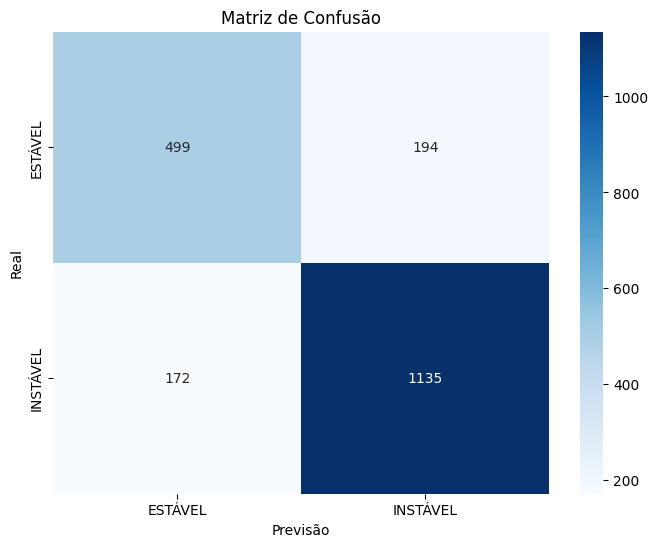

In [23]:
cm = confusion_matrix(y_test, y_predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ESTÁVEL', 'INSTÁVEL'], yticklabels=['ESTÁVEL', 'INSTÁVEL'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()